In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    roc_auc_score, confusion_matrix, classification_report, roc_curve, auc
)
import pickle
import warnings
warnings.filterwarnings('ignore')

In [67]:
# Load processed data
processed_data = pd.read_csv('../churn-prediction-enhanced/data/churn_processed.csv')
print(f"Loaded data shape: {processed_data.shape}")
print(f"Columns: {processed_data.columns.tolist()[:10]}...")  # Show first 10 columns

# Find churn column
churn_col = None
for col in processed_data.columns:
    if 'churn' in col.lower():
        churn_col = col
        break

print(f"\nTarget column: {churn_col}")

Loaded data shape: (10000, 49)
Columns: ['customer_id', 'age', 'tenure_months', 'monthly_logins', 'weekly_active_days', 'avg_session_time', 'features_used', 'usage_growth_rate', 'last_login_days_ago', 'monthly_fee']...

Target column: churn


In [85]:
# Separate features and target
X = processed_data.drop(columns=['customer_id',churn_col])
y = processed_data[churn_col]

X['tenure_segment'] = X['tenure_segment'].map({
    '0-6 months': 0,
    '6-12 months': 1,
    '12-24 months': 2,
    '24+ months': 3
})

# Convert target to binary (0/1) if needed
if y.dtype == 'object':
    y = (y == y.unique()[1]).astype(int)  # Converts to 1 for churn, 0 for no churn


print(f"Features shape: {X.shape}")
print(f"Target distribution:")
print(y.value_counts())
print(f"\nChurn rate: {y.mean()*100:.2f}%")

# Train-test split (80-20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTrain set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

Features shape: (10000, 47)
Target distribution:
churn
0    8979
1    1021
Name: count, dtype: int64

Churn rate: 10.21%

Train set: (8000, 47)
Test set: (2000, 47)


In [86]:
print(X.shape,X_train.shape,X_test.shape)

(10000, 47) (8000, 47) (2000, 47)


In [87]:
print(y.shape,y_train.shape,y_test.shape)

(10000,) (8000,) (2000,)


In [88]:
print(X.select_dtypes(include='object').columns)

Index([], dtype='object')


In [89]:
print(X_train['tenure_segment'].dtype)

int64


In [90]:
# Scale features

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✓ Features scaled using StandardScaler")

✓ Features scaled using StandardScaler


In [91]:
# Train multiple models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost': XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')
}

results = {}

for name, model in models.items():
    print(f"\nTraining {name}...")
    
    if name == 'Logistic Regression':
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_pred_proba = model.predict_proba(X_test)[:, 1]
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    
    results[name] = {
        'model': model,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'roc_auc': roc_auc,
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba
    }
    
    print(f"✓ Accuracy: {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall: {recall:.4f}")
    print(f"  F1-Score: {f1:.4f}")
    print(f"  ROC-AUC: {roc_auc:.4f}")


Training Logistic Regression...
✓ Accuracy: 0.8970
  Precision: 0.4000
  Recall: 0.0196
  F1-Score: 0.0374
  ROC-AUC: 0.7385

Training Random Forest...
✓ Accuracy: 0.8980
  Precision: 0.5000
  Recall: 0.0049
  F1-Score: 0.0097
  ROC-AUC: 0.7968

Training XGBoost...
✓ Accuracy: 0.8845
  Precision: 0.2128
  Recall: 0.0490
  F1-Score: 0.0797
  ROC-AUC: 0.7568



Model Comparison:
                     Accuracy  Precision  Recall  F1-Score  ROC-AUC
Logistic Regression    0.8970     0.4000  0.0196    0.0374   0.7385
Random Forest          0.8980     0.5000  0.0049    0.0097   0.7968
XGBoost                0.8845     0.2128  0.0490    0.0797   0.7568


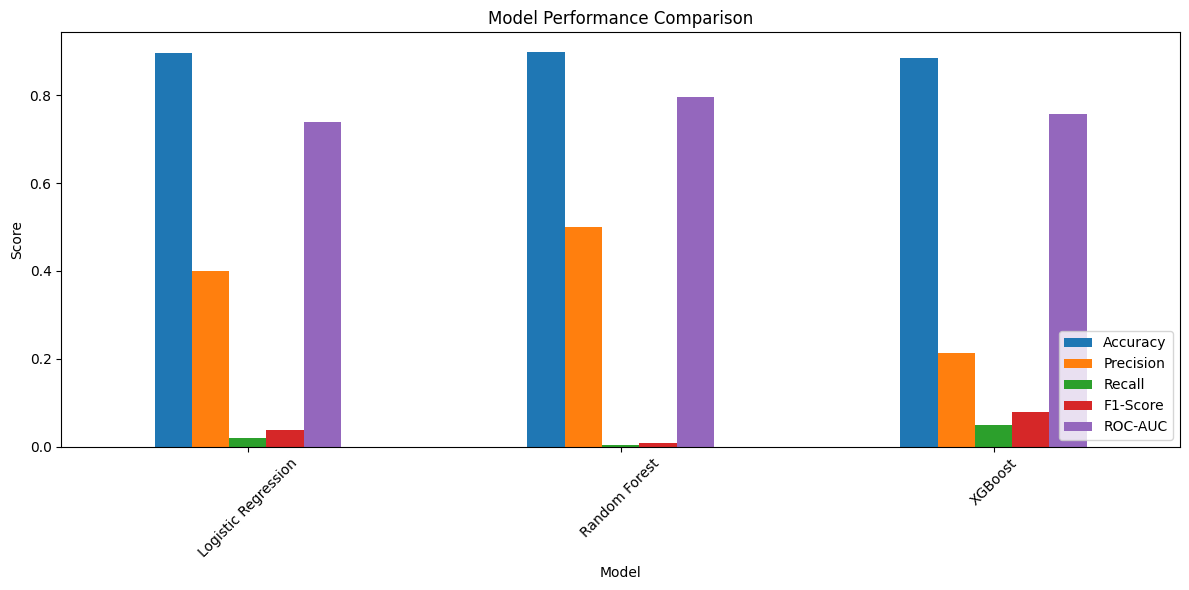

In [93]:
# Compare all models
comparison_df = pd.DataFrame({
    'Accuracy': {name: results[name]['accuracy'] for name in results},
    'Precision': {name: results[name]['precision'] for name in results},
    'Recall': {name: results[name]['recall'] for name in results},
    'F1-Score': {name: results[name]['f1'] for name in results},
    'ROC-AUC': {name: results[name]['roc_auc'] for name in results}
})

print("\nModel Comparison:")
print(comparison_df.round(4))

# Visualize
comparison_df.plot(kind='bar', figsize=(12, 6))
plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.xlabel('Model')
plt.xticks(rotation=45)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [94]:
# Select best model (by F1 score)
best_model_name = max(results, key=lambda x: results[x]['f1'])
best_model = results[best_model_name]['model']
y_pred_best = results[best_model_name]['y_pred']

print(f"\nBest Model: {best_model_name}")
print("="*50)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_best)
print("\nConfusion Matrix:")
print(cm)

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_best, target_names=['No Churn', 'Churn']))


Best Model: XGBoost

Confusion Matrix:
[[1759   37]
 [ 194   10]]

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.90      0.98      0.94      1796
       Churn       0.21      0.05      0.08       204

    accuracy                           0.88      2000
   macro avg       0.56      0.51      0.51      2000
weighted avg       0.83      0.88      0.85      2000



What is the F1-score?

The F1-score combines Precision and Recall into a single metric.

Precision: Of the customers predicted to churn, how many actually churned?
Recall: Of all customers who actually churned, how many did the model find?

The F1-score balances both.

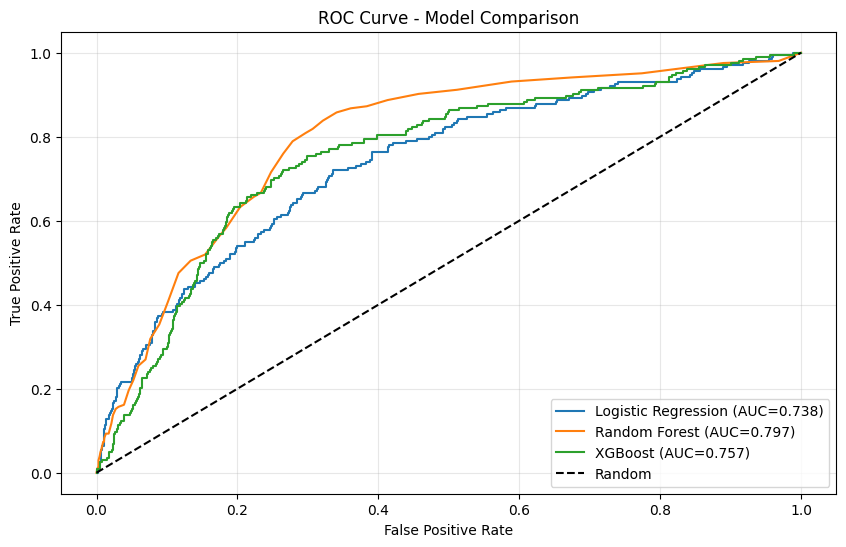

In [95]:
# Plot ROC curves for all models
plt.figure(figsize=(10, 6))

for name in results:
    y_pred_proba = results[name]['y_pred_proba']
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC={roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Model Comparison')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


Top 15 Important Features:
                    feature  importance
13               csat_score    0.098539
10         payment_failures    0.070440
1             tenure_months    0.043876
2            monthly_logins    0.030336
34     customer_segment_SME    0.027269
21       country_Bangladesh    0.026009
31              city_Sydney    0.025262
22           country_Canada    0.024737
43   complaint_type_Service    0.023222
35  signup_channel_Referral    0.022124
8               monthly_fee    0.021810
7       last_login_days_ago    0.021215
32             city_Toronto    0.020938
41     discount_applied_Yes    0.020130
27               city_Delhi    0.019983


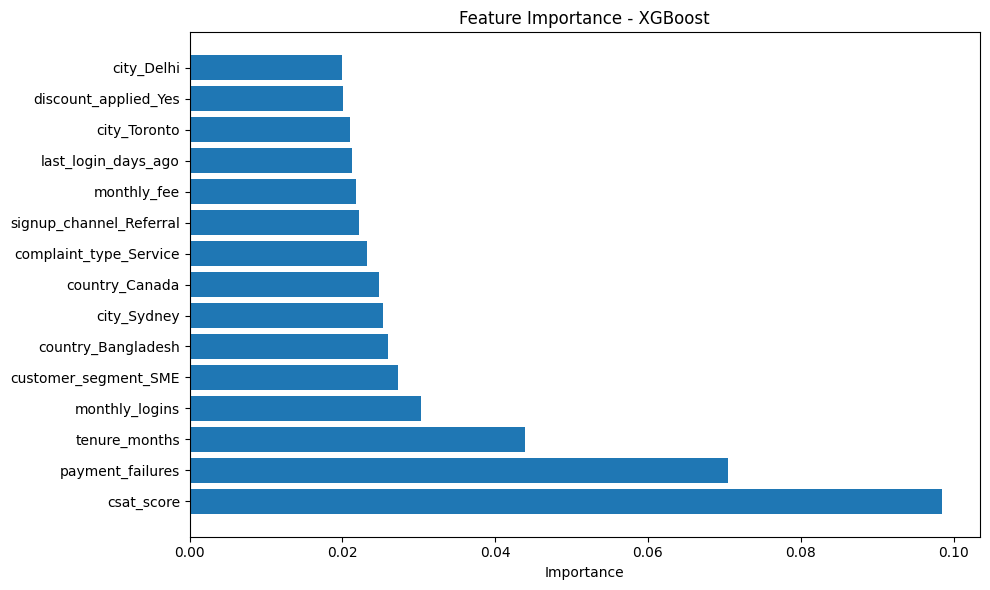

In [96]:
if best_model_name in ['Random Forest', 'XGBoost']:
    feature_importance = pd.DataFrame({
        'feature': X.columns,
        'importance': best_model.feature_importances_
    }).sort_values('importance', ascending=False).head(15)
    
    print("\nTop 15 Important Features:")
    print(feature_importance)
    
    # Visualize
    plt.figure(figsize=(10, 6))
    plt.barh(feature_importance['feature'], feature_importance['importance'])
    plt.xlabel('Importance')
    plt.title(f'Feature Importance - {best_model_name}')
    plt.tight_layout()
    plt.show()

In [100]:
# Save model
model_path = '../churn-prediction-enhanced/models/trained_model.pkl' 
with open(model_path, 'wb') as f:
    pickle.dump(best_model, f)

# Save scaler too
scaler_path = '../churn-prediction-enhanced/models/scaler.pkl'
with open(scaler_path, 'wb') as f:
    pickle.dump(scaler, f)

print(f"✓ Model saved: {model_path}")
print(f"✓ Scaler saved: {scaler_path}")

✓ Model saved: ../churn-prediction-enhanced/models/trained_model.pkl
✓ Scaler saved: ../churn-prediction-enhanced/models/scaler.pkl


In [101]:
print("="*50)
print(f"BEST MODEL: {best_model_name}")
print("="*50)
print(f"\n✓ Accuracy:  {results[best_model_name]['accuracy']:.4f}")
print(f"✓ Precision: {results[best_model_name]['precision']:.4f}")
print(f"✓ Recall:    {results[best_model_name]['recall']:.4f}")
print(f"✓ F1-Score:  {results[best_model_name]['f1']:.4f}")
print(f"✓ ROC-AUC:   {results[best_model_name]['roc_auc']:.4f}")
print("\n✓ Next: Run 03_causal_analysis.ipynb for SHAP analysis!")

BEST MODEL: XGBoost

✓ Accuracy:  0.8845
✓ Precision: 0.2128
✓ Recall:    0.0490
✓ F1-Score:  0.0797
✓ ROC-AUC:   0.7568

✓ Next: Run 03_causal_analysis.ipynb for SHAP analysis!
